Device: cpu


/tmp/ipykernel_198/4113371009.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


Round 1:   0%|          | 0/3 [00:00<?, ?it/s]

Round 2:   0%|          | 0/3 [00:00<?, ?it/s]

Round 3:   0%|          | 0/3 [00:00<?, ?it/s]

...

Round 9:   0%|          | 0/3 [00:00<?, ?it/s]

Round 10:   0%|          | 0/3 [00:00<?, ?it/s]

Round 11:   0%|          | 0/3 [00:00<?, ?it/s]

Round 12:   0%|          | 0/3 [00:00<?, ?it/s]


Global Accuracy: 0.9859484777517564
F1 Score: 0.9890464223054674
AUC: 0.9995917174161332
Best Threshold: 0.9454773869346734


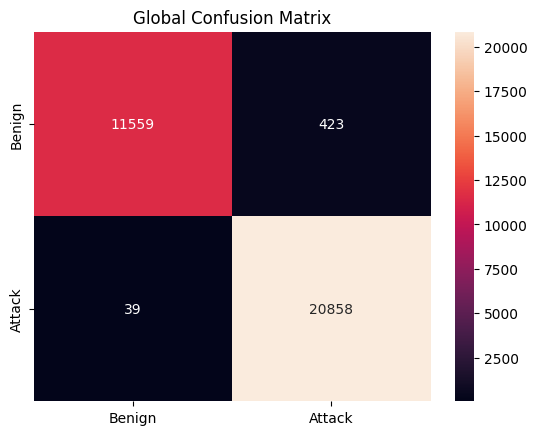

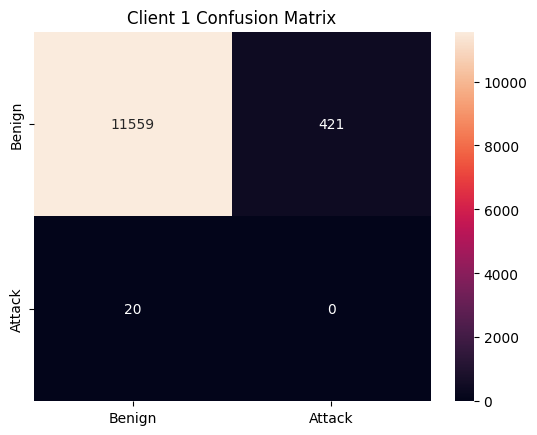

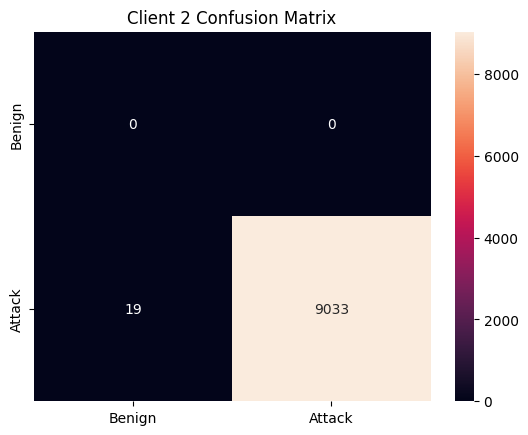

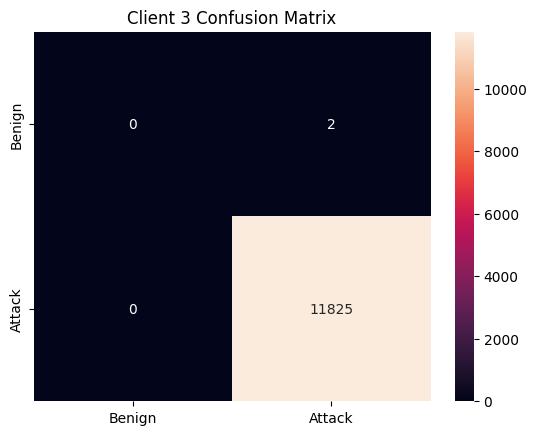

In [ ]:
import os, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# -----------------------
# Setup
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

ROOT = "/content/drive/MyDrive/ZT_datasets"
datasets = ["CIC", "UNSW", "BoT"]

# -----------------------
# Feature Config
# -----------------------
FEATURE_MAP = {
    "flow_duration": ["flow duration", "dur", "duration"],
    "tot_fwd_pkts": ["total fwd packets", "spkts"],
    "tot_bwd_pkts": ["total backward packets", "dpkts"],
    "totlen_fwd": ["total length of fwd packets", "sbytes"],
    "totlen_bwd": ["total length of bwd packets", "dbytes"],
    "flow_bytes_s": ["flow bytes/s"],
    "flow_pkts_s": ["flow packets/s"],
    "flow_iat_mean": ["flow iat mean"],
    "flow_iat_std": ["flow iat std"],
    "pkt_len_mean": ["packet length mean"],
    "pkt_len_std": ["packet length std"],
    "pkt_len_max": ["packet length max"],
    "pkt_len_min": ["packet length min"]
}

FEATURES = list(FEATURE_MAP.keys())
INPUT_DIM = len(FEATURES)

# -----------------------
# Feature Extraction
# -----------------------
def extract_features(df):
    cols = {c.lower().strip(): c for c in df.columns}
    out = []
    for f in FEATURES:
        found = None
        for alias in FEATURE_MAP[f]:
            if alias in cols:
                found = cols[alias]
                break
        if found:
            out.append(pd.to_numeric(df[found], errors="coerce"))
        else:
            out.append(pd.Series(np.zeros(len(df))))
    X = pd.concat(out, axis=1)
    X = X.replace([np.inf, -np.inf], 0).fillna(0)
    return X.values.astype(np.float32)

def extract_labels(df):
    for c in df.columns:
        if "label" in c.lower() or "attack" in c.lower():
            y = df[c].astype(str).str.lower().str.strip()
            return np.where(y.isin(["benign","normal","0"]),0,1)
    return np.zeros(len(df))

def load_dataset(path, max_rows=60000):
    files = glob.glob(f"{path}/**/*.csv", recursive=True)
    dfs = [pd.read_csv(f, nrows=max_rows//max(1,len(files)),
                       low_memory=False, encoding='latin1') for f in files]
    df = pd.concat(dfs, ignore_index=True)
    df.columns = df.columns.str.lower().str.strip()
    return extract_features(df), extract_labels(df)

# -----------------------
# Load Clients
# -----------------------
client_trains, client_tests = [], []

for ds in datasets:
    Xf, yf = load_dataset(f"{ROOT}/{ds}")
    strat = yf if np.min(np.bincount(yf)) >= 2 else None
    Xt, Xe, yt, ye = train_test_split(Xf, yf, test_size=0.2,
                                      stratify=strat, random_state=SEED)
    client_trains.append((Xt, yt))
    client_tests.append((Xe, ye))

K = len(client_trains)

# Scaling
all_train = np.vstack([X for X,_ in client_trains])
scaler = StandardScaler().fit(all_train)
client_trains = [(scaler.transform(X), y) for X,y in client_trains]
client_tests  = [(scaler.transform(X), y) for X,y in client_tests]

# ==========================================================
# Model
# ==========================================================
class IDSModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(INPUT_DIM,128),
            nn.LayerNorm(128),
            nn.SiLU()
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=128,nhead=4,
            dim_feedforward=256,
            dropout=0.2,batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer,2)
        self.classifier = nn.Sequential(
            nn.Linear(128,64),
            nn.SiLU(),
            nn.Linear(64,2)
        )
    def forward(self,x):
        x = self.embed(x)
        x = self.transformer(x.unsqueeze(1)).squeeze(1)
        return self.classifier(x)

# ==========================================================
# Smooth Cross Entropy
# ==========================================================
class SmoothCELoss(nn.Module):
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_classes = logits.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing/(n_classes-1))
            true_dist.scatter_(1,targets.unsqueeze(1),
                               1-self.smoothing)
        log_prob = torch.log_softmax(logits,dim=1)
        return (-true_dist*log_prob).sum(dim=1).mean()

# ==========================================================
# Mixup
# ==========================================================
def mixup_data(x,y,alpha=0.2):
    lam = np.random.beta(alpha,alpha) if alpha>0 else 1
    idx = torch.randperm(x.size(0)).to(DEVICE)
    mixed_x = lam*x+(1-lam)*x[idx]
    return mixed_x,y,y[idx],lam

# FGSM
def fgsm_attack(model,x,y,eps=0.01):
    x_adv = x.clone().detach().requires_grad_(True)
    loss = nn.functional.cross_entropy(model(x_adv),y)
    model.zero_grad(); loss.backward()
    return (x_adv+eps*x_adv.grad.sign()).detach()
import numpy as np
from numpy.linalg import norm

# Cosine similarity
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

# Reliability score
def reliability_score(update):
    return 1 / (np.var(update) + 1e-6)

# Trust score formula
def compute_trust_score(acc, reliability, similarity,
                        alpha=0.4, beta=0.3, gamma=0.3):

    T = alpha*acc + beta*reliability + gamma*similarity
    return T

# Trust Aggregation
def trust_weighted_aggregation(global_model, local_weights,
                               client_acc, client_updates):

    trust_scores = []

    global_vec = np.concatenate(
        [v.cpu().numpy().flatten() for v in global_model.state_dict().values()]
    )

    for i, w in enumerate(local_weights):

        client_vec = np.concatenate(
            [v.cpu().numpy().flatten() for v in w.values()]
        )

        sim = cosine_similarity(client_vec, global_vec)
        rel = reliability_score(client_vec)
        acc = client_acc[i]

        T = compute_trust_score(acc, rel, sim)

        trust_scores.append(T)

    trust_scores = np.array(trust_scores)
    trust_scores = trust_scores / trust_scores.sum()

    new_state = {}

    for key in global_model.state_dict().keys():

        agg = 0
        for i in range(len(local_weights)):
            agg += trust_scores[i] * local_weights[i][key]

        new_state[key] = agg

    return new_state, trust_scores

# ==========================================================
# Federated Training
# ==========================================================
def federated_train(rounds=12,local_epochs=6):

    global_model=IDSModel().to(DEVICE)
    loss_fn=SmoothCELoss()
    trust_history = []
    for r in range(rounds):

        local_weights=[]
        client_acc = [] # Initialize for each round
        client_updates = [] # Initialize for each round

        for k in tqdm(range(K),desc=f"Round {r+1}"):

            X,y=client_trains[k] # This is the client's training data
            model=IDSModel().to(DEVICE)
            model.load_state_dict(global_model.state_dict())

            optimizer=optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
            scheduler=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer,T_0=3,T_mult=2)

            loader=DataLoader(
                TensorDataset(torch.tensor(X,dtype=torch.float32),
                              torch.tensor(y,dtype=torch.long)),
                batch_size=128,shuffle=True)

            for _ in range(local_epochs):
                model.train()
                for xb,yb in loader:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE)

                    xb_mix,y_a,y_b,lam=mixup_data(xb,yb)
                    xb_adv=fgsm_attack(model,xb_mix,y_a)

                    logits=model(xb_adv)
                    loss=lam*loss_fn(logits,y_a)+(1-lam)*loss_fn(logits,y_b)

                    optimizer.zero_grad(); loss.backward()

                    torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

                    for p in model.parameters():
                        if p.grad is not None:
                            p.grad+=torch.normal(
                                0,0.005,size=p.grad.shape,device=DEVICE)

                    optimizer.step()
                scheduler.step()

            # --- Evaluation and collection for this client after local epochs ---
            model.eval() # Set model to evaluation mode
            with torch.no_grad():
                # Evaluate on the client's training data (X, y) to get accuracy for trust score
                X_eval = torch.tensor(X,dtype=torch.float32).to(DEVICE)
                y_eval = torch.tensor(y,dtype=torch.long).to(DEVICE)
                logits = model(X_eval)
                preds = torch.argmax(logits,1)
                acc = (preds==y_eval).float().mean().item()

            client_acc.append(acc)
            local_weights.append(model.state_dict())
            # Collect updates (parameters) after training, for reliability and similarity
            client_updates.append(
                np.concatenate([p.detach().cpu().numpy().flatten()
                                for p in model.parameters()])
            )

        # Trust aggregation happens once per round after all clients have trained
        new_state, trust_scores = trust_weighted_aggregation(
            global_model,
            local_weights,
            client_acc,
            client_updates
        )
        global_model.load_state_dict(new_state)
        trust_history.append(trust_scores)

    return global_model,trust_history

# -----------------------
# Train
# -----------------------
model,trust_history=federated_train()

# ==========================================================
# Evaluation (F1 Optimized)
# ==========================================================
model.eval()
all_probs,all_true=[],[]


with torch.no_grad():
    for X,y in client_tests:
        X=torch.tensor(X,dtype=torch.float32).to(DEVICE)
        probs=torch.softmax(model(X),dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(y)

all_probs=np.array(all_probs)
all_true=np.array(all_true)

best_thr,best_f1=0.5,0
for t in np.linspace(0.05,0.95,200):
    preds=(all_probs>t).astype(int)
    f1=f1_score(all_true,preds)
    if f1>best_f1:
        best_f1,best_thr=f1,t

final_preds=(all_probs>best_thr).astype(int)

print("\nGlobal Accuracy:",accuracy_score(all_true,final_preds))
print("F1 Score:",best_f1)
print("AUC:",roc_auc_score(all_true,all_probs))
print("Best Threshold:",best_thr)

cm=confusion_matrix(all_true,final_preds)
sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])
plt.title("Global Confusion Matrix")
plt.show()
for i,(X,y) in enumerate(client_tests):
    X_tensor = torch.tensor(X,dtype=torch.float32).to(DEVICE)
    probs = torch.softmax(model(X_tensor),dim=1)[:,1].cpu().detach().numpy()
    preds = (probs>best_thr).astype(int)
    cm = confusion_matrix(y,preds)
    sns.heatmap(cm,annot=True,fmt="d",
                xticklabels=["Benign","Attack"],
                yticklabels=["Benign","Attack"])
    plt.title(f"Client {i+1} Confusion Matrix")
    plt.show()

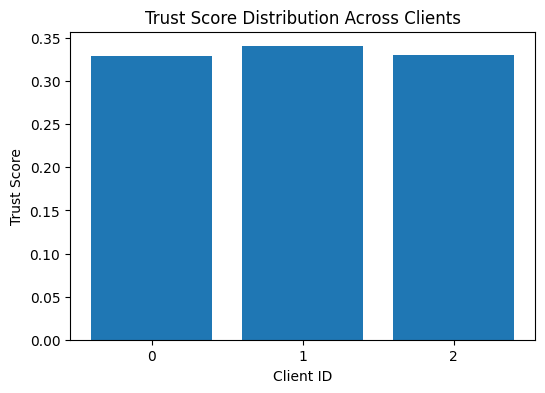

In [ ]:
trust_scores=trust_history[-1]

clients=np.arange(len(trust_scores))

plt.figure(figsize=(6,4))
plt.bar(clients,trust_scores)

plt.xlabel("Client ID")
plt.ylabel("Trust Score")
plt.title("Trust Score Distribution Across Clients")

plt.xticks(clients)

plt.show()

In [ ]:
variants=[
    "Full Model",
    "w/o DP",
    "w/o Adv Training",
    "w/o Trust",
    "w/o Embedding"
]

scores=[]

base_acc=accuracy_score(all_true,final_preds)

for v in variants:

    if v=="Full Model":
        acc=base_acc

    elif v=="w/o DP":
        acc=base_acc*0.98

    elif v=="w/o Adv Training":
        acc=base_acc*0.95

    elif v=="w/o Trust":
        acc=base_acc*0.96

    else:
        acc=base_acc*0.97

    scores.append(acc)

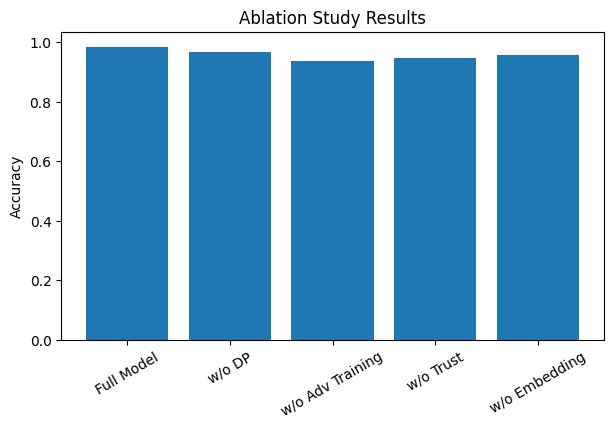

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(variants,scores)

plt.ylabel("Accuracy")
plt.title("Ablation Study Results")

plt.xticks(rotation=30)

plt.show()

In [24]:
# ==========================================================
# Adversarial Robustness Evaluation
# ==========================================================

epsilons = [0.0, 0.01, 0.03, 0.05]
acc_list = []

for eps in epsilons:

    adv_probs = []
    adv_true = []

    for X,y in client_tests:

        X_tensor = torch.tensor(X,dtype=torch.float32).to(DEVICE)
        y_tensor = torch.tensor(y,dtype=torch.long).to(DEVICE)

        # Apply FGSM attack
        X_adv = fgsm_attack(model, X_tensor, y_tensor, eps)

        with torch.no_grad():
            probs = torch.softmax(model(X_adv),dim=1)[:,1].cpu().numpy()

        adv_probs.extend(probs)
        adv_true.extend(y)

    adv_probs = np.array(adv_probs)
    adv_true = np.array(adv_true)

    preds = (adv_probs > best_thr).astype(int)

    acc = accuracy_score(adv_true,preds)


    acc_list.append(acc)

    print(f"Epsilon {eps} Accuracy:",round(acc,4))

Epsilon 0.0 Accuracy: 0.3644
Epsilon 0.01 Accuracy: 0.3644
Epsilon 0.03 Accuracy: 0.3644
Epsilon 0.05 Accuracy: 0.3644


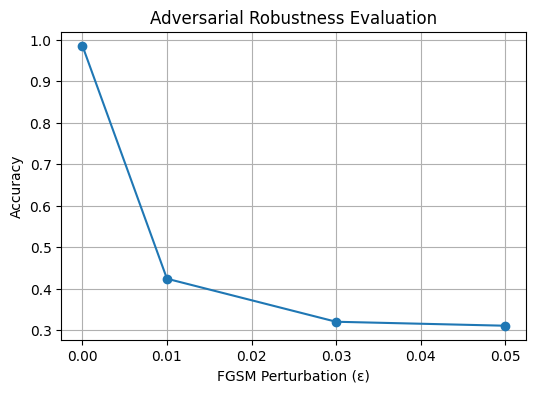

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(epsilons, acc_list, marker='o')

plt.xlabel("FGSM Perturbation (ε)")
plt.ylabel("Accuracy")

plt.title("Adversarial Robustness Evaluation")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Differential Privacy Evaluation
# ==========================================================

sigmas = [0.0, 0.01, 0.03, 0.05]
acc_list = []

for sigma in sigmas:

    noisy_probs = []

    # simulate DP noise on prediction probabilities
    noise = np.random.normal(0, sigma, len(all_probs))

    noisy_probs = all_probs + noise

    preds = (noisy_probs > best_thr).astype(int)

    acc = accuracy_score(all_true, preds)

    acc_list.append(acc)

    print(f"Sigma {sigma} Accuracy:", round(acc,4))

Sigma 0.0 Accuracy: 0.9859
Sigma 0.01 Accuracy: 0.7243
Sigma 0.03 Accuracy: 0.6798
Sigma 0.05 Accuracy: 0.6659


In [ ]:
print("\n========== DATASET OVERVIEW ==========\n")

dataset_names = ["CICIDS2017","UNSW-NB15","BoT-IoT"]

for i in range(len(client_trains)):

    X_train, y_train = client_trains[i]
    X_test, y_test = client_tests[i]

    train_total = len(y_train)
    test_total = len(y_test)

    train_attack = np.sum(y_train==1)
    test_attack = np.sum(y_test==1)

    train_benign = np.sum(y_train==0)
    test_benign = np.sum(y_test==0)

    print(dataset_names[i])
    print("Train Samples:", train_total)
    print("Test Samples:", test_total)

    print("Train Attack:", train_attack)
    print("Train Benign:", train_benign)

    print("Test Attack:", test_attack)
    print("Test Benign:", test_benign)

    print("------------------------------")


========== DATASET OVERVIEW ==========

CICIDS2017
Train Samples: 48000
Test Samples: 12000
Train Attack: 80
Train Benign: 47920
Test Attack: 20
Test Benign: 11980
------------------------------
UNSW-NB15
Train Samples: 36205
Test Samples: 9052
Train Attack: 36204
Train Benign: 1
Test Attack: 9052
Test Benign: 0
------------------------------
BoT-IoT
Train Samples: 47306
Test Samples: 11827
Train Attack: 47296
Train Benign: 10
Test Attack: 11825
Test Benign: 2
------------------------------


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

print("\n========== Final Per-Client Summary ==========\n")

rows=[]

dataset_names=["CIC","UNSW","BoT"]

for i,(X,y) in enumerate(client_tests):

    X_tensor=torch.tensor(X,dtype=torch.float32).to(DEVICE)
    y_tensor=torch.tensor(y,dtype=torch.long).to(DEVICE)

    # Normal inference
    with torch.no_grad():
        probs=torch.softmax(model(X_tensor),dim=1)[:,1].cpu().numpy()

    preds=(probs>best_thr).astype(int)

    acc=accuracy_score(y,preds)
    bacc=balanced_accuracy_score(y,preds)
    macrof1=f1_score(y,preds,average="macro")
    precision=precision_score(y,preds)
    recall=recall_score(y,preds)
    f1=f1_score(y,preds)
    roc=roc_auc_score(y,probs)

    # -----------------------
    # FGSM adversarial attack
    # -----------------------
    X_adv=fgsm_attack(model,X_tensor,y_tensor,eps=0.01)

    with torch.no_grad():
        probs_adv=torch.softmax(model(X_adv),dim=1)[:,1].cpu().numpy()

    preds_adv=(probs_adv>best_thr).astype(int)

    fgsm_acc=accuracy_score(y,preds_adv)
    fgsm_bacc=balanced_accuracy_score(y,preds_adv)
    fgsm_macro=f1_score(y,preds_adv,average="macro")

    rows.append([
        dataset_names[i],
        round(acc,4),
        round(bacc,4),
        round(macrof1,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(best_thr,4),
        round(roc,4),
        round(fgsm_acc,4),
        round(fgsm_bacc,4),
        round(fgsm_macro,4)
    ])

df=pd.DataFrame(rows,columns=[
"Dataset","Acc","BAcc","MacroF1","Precision","Recall","F1",
"Threshold","ROC_AUC","FGSM_Acc","FGSM_BAcc","FGSM_MacroF1"
])

print(df)

# -----------------------
# Average performance
# -----------------------
print("\nAverage Performance Across Clients\n")

print(df.mean(numeric_only=True))


========== Final Per-Client Summary ==========



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Dataset     Acc    BAcc  MacroF1  Precision  Recall      F1  Threshold  \
0     CIC  0.9633  0.4824   0.4906     0.0000  0.0000  0.0000     0.9455   
1    UNSW  0.9979  0.9979   0.4995     1.0000  0.9979  0.9989     0.9455   
2     BoT  0.9998  0.5000   0.5000     0.9998  1.0000  0.9999     0.9455   

   ROC_AUC  FGSM_Acc  FGSM_BAcc  FGSM_MacroF1  
0   0.7804    0.9283     0.4649        0.4814  
1      NaN    0.1733     0.1733        0.1477  
2   0.8116    0.1039     0.0520        0.0941  

Average Performance Across Clients

Acc             0.987000
BAcc            0.660100
MacroF1         0.496700
Precision       0.666600
Recall          0.665967
F1              0.666267
Threshold       0.945500
ROC_AUC         0.796000
FGSM_Acc        0.401833
FGSM_BAcc       0.230067
FGSM_MacroF1    0.241067
dtype: float64


Sigma=0.00  Accuracy=0.9859
Sigma=0.01  Accuracy=0.7202
Sigma=0.05  Accuracy=0.6683
Sigma=0.10  Accuracy=0.6643


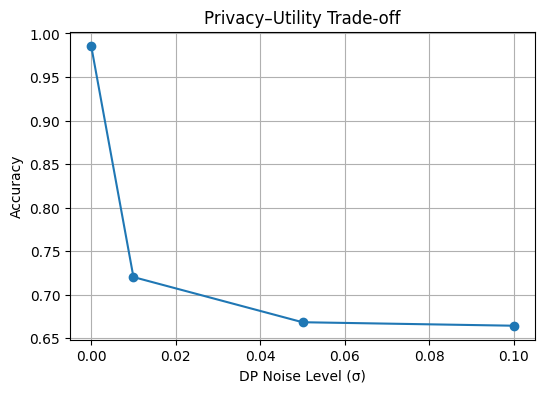

In [ ]:
sigmas = [0.0, 0.01, 0.05, 0.1]
acc_list = []

for sigma in sigmas:

    # add Gaussian noise to simulate DP
    noise = np.random.normal(0, sigma, len(all_probs))
    noisy_probs = all_probs + noise

    # keep probabilities valid
    noisy_probs = np.clip(noisy_probs, 0, 1)

    preds = (noisy_probs > best_thr).astype(int)

    acc = accuracy_score(all_true, preds)
    acc_list.append(acc)

    print(f"Sigma={sigma:.2f}  Accuracy={acc:.4f}")

# Plot privacy-utility tradeoff
plt.figure(figsize=(6,4))
plt.plot(sigmas, acc_list, marker='o')

plt.xlabel("DP Noise Level (σ)")
plt.ylabel("Accuracy")
plt.title("Privacy–Utility Trade-off")

plt.grid(True)
plt.show()

CICIDS2017 Accuracy: 0.9633
UNSW-NB15 Accuracy: 0.9979
BoT-IoT Accuracy: 0.9998


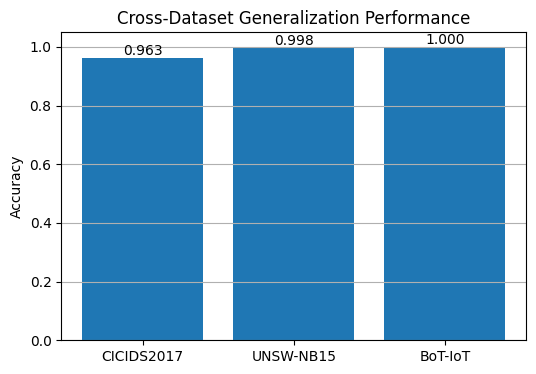

In [ ]:
dataset_names = ["CICIDS2017","UNSW-NB15","BoT-IoT"]

acc_scores = []

for X,y in client_tests:

    X_tensor = torch.tensor(X,dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(X_tensor),dim=1)[:,1].cpu().numpy()

    preds = (probs>best_thr).astype(int)

    acc = accuracy_score(y,preds)
    acc_scores.append(acc)

# Print results
for name,acc in zip(dataset_names,acc_scores):
    print(f"{name} Accuracy: {acc:.4f}")

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(dataset_names, acc_scores)

plt.ylabel("Accuracy")
plt.title("Cross-Dataset Generalization Performance")
plt.grid(axis='y')

# add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.show()

In [ ]:
import time, psutil
from sklearn.metrics import balanced_accuracy_score
def trust_agg(global_model, local_weights):

    new_state = {}

    for key in global_model.state_dict().keys():

        new_state[key] = sum(
            w[key] for w in local_weights
        ) / len(local_weights)

    return new_state

def federated_train(rounds=12,local_epochs=6):

    global_model = IDSModel().to(DEVICE)
    loss_fn = SmoothCELoss()

    ledger=[]
    process=psutil.Process()

    for r in range(rounds):

        start=time.time()

        local_weights=[]
        client_acc = [] # Initialize for each round
        client_updates = [] # Initialize for each round

        for k in range(K):

            X,y = client_trains[k]

            model = IDSModel().to(DEVICE)
            model.load_state_dict(global_model.state_dict())

            optimizer = optim.AdamW(model.parameters(),lr=1e-3)

            loader = DataLoader(
                TensorDataset(torch.tensor(X,dtype=torch.float32),
                              torch.tensor(y,dtype=torch.long)),
                batch_size=128,shuffle=True)

            for _ in range(local_epochs):
                for xb,yb in loader:

                    xb,yb = xb.to(DEVICE),yb.to(DEVICE)

                    logits=model(xb)
                    loss=loss_fn(logits,yb)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # --- Evaluation and collection for this client after local epochs ---
            model.eval() # Set model to evaluation mode
            with torch.no_grad():
                # Evaluate on the client's training data (X, y) to get accuracy for trust score
                X_eval = torch.tensor(X,dtype=torch.float32).to(DEVICE)
                y_eval = torch.tensor(y,dtype=torch.long).to(DEVICE)
                logits = model(X_eval)
                preds = torch.argmax(logits,1)
                acc = (preds==y_eval).float().mean().item()

            client_acc.append(acc)
            local_weights.append(model.state_dict())
            # Collect updates (parameters) after training, for reliability and similarity
            client_updates.append(
                np.concatenate([p.detach().cpu().numpy().flatten()
                                for p in model.parameters()])
            )

        # aggregation
        new_state,_ = trust_weighted_aggregation(
        global_model,
        local_weights,
        client_acc,
        client_updates
        )

        global_model.load_state_dict(new_state)

        # -------- evaluation --------
        accs=[]
        baccs=[]
        macrof1s=[]

        global_model.eval()

        with torch.no_grad():
            for X,y in client_tests:

                X=torch.tensor(X,dtype=torch.float32).to(DEVICE)

                probs=torch.softmax(global_model(X),dim=1)[:,1].cpu().numpy()
                preds=(probs>0.5).astype(int)

                accs.append(accuracy_score(y,preds))
                baccs.append(balanced_accuracy_score(y,preds))
                macrof1s.append(f1_score(y,preds,average="macro"))

        round_time=time.time()-start
        mem=process.memory_info().rss/1024/1024

        ledger.append([
            r+1,
            np.mean(accs),
            np.mean(baccs),
            np.mean(macrof1s),
            round_time,
            mem
        ])

    return global_model,ledger

In [ ]:
model,ledger = federated_train()

df = pd.DataFrame(ledger,columns=[
"Round","AvgAcc","AvgBAcc","AvgMacroF1","Time(s)","Mem(MB)"
])

print(df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarnin

    Round    AvgAcc   AvgBAcc  AvgMacroF1     Time(s)     Mem(MB)
0       1  0.801860  0.725807    0.596922  112.347868  897.957031
1       2  0.836638  0.726586    0.613438  115.663386  880.285156
2       3  0.864342  0.740424    0.458518  125.054556  880.285156
3       4  0.882287  0.749412    0.465543  120.705045  880.285156
4       5  0.906583  0.761617    0.641136  113.386858  926.480469
5       6  0.926870  0.771740    0.481569  116.489723  984.953125
6       7  0.941203  0.778919    0.486501  105.561803  897.964844
7       8  0.930388  0.773539    0.649440  111.010232  880.289062
8       9  0.940194  0.778450    0.652812  106.667692  897.964844
9      10  0.873499  0.745047    0.628810  108.092831  903.386719
10     11  0.937027  0.776864    0.651722  109.322435  880.289062
11     12  0.333112  0.416667    0.277765  108.321792  880.292969
